In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("data/[Data] Students_dropout_academic_success.csv")

In [3]:
df.head()

,Gender,Age at enrollment,Marital status,Application mode,Course,Scholarship holder,Admission grade,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Target
0,Male,37,Single,Transfer,Management,No,113.2,4,2,12.4,14.2,Graduate
1,Female,39,Single,Special,Psychology,Yes,128.4,4,3,13.9,15.3,Enrolled
2,Male,17,Single,Transfer,Engineering,Yes,115.2,4,3,12.9,16.3,Graduate
3,Male,19,Single,Online,Computer Science,Yes,123.0,4,3,14.1,13.9,Dropout
4,Male,34,Single,Exam,Psychology,No,151.5,7,5,12.3,11.7,Enrolled


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Gender                               500 non-null    object 
 1   Age at enrollment                    500 non-null    int64  
 2   Marital status                       500 non-null    object 
 3   Application mode                     500 non-null    object 
 4   Course                               500 non-null    object 
 5   Scholarship holder                   500 non-null    object 
 6   Admission grade                      500 non-null    float64
 7   Curricular units 1st sem (enrolled)  500 non-null    int64  
 8   Curricular units 1st sem (approved)  500 non-null    int64  
 9   Curricular units 1st sem (grade)     500 non-null    float64
 10  Curricular units 2nd sem (grade)     500 non-null    float64
 11  Target                          

In [5]:
# Check NULL
print("Null:", df.isnull().sum().sum())
# Check duplicate
print("Duplicated:", df.duplicated().sum())

Null: 0
Duplicated: 0


# Bài 1 – Phân phối điểm số đầu vào
Yêu cầu:

Vẽ histogram cho biến Admission grade.
Tính giá trị trung bình, trung vị, độ lệch chuẩn.
Nhận xét: điểm đầu vào phân phối tập trung ở khoảng nào?


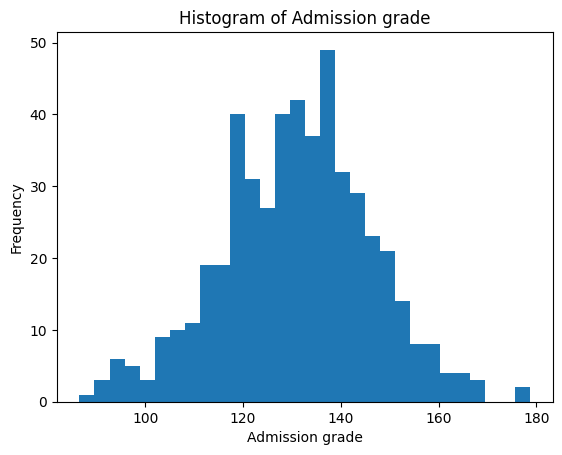

In [6]:
plt.figure()
plt.hist(df["Admission grade"], bins=30)
plt.xlabel("Admission grade")
plt.ylabel("Frequency")
plt.title("Histogram of Admission grade")
plt.show()

In [7]:
print("Trung bình:", df["Admission grade"].mean())
print("Trung vị:", df["Admission grade"].median())
print("Độ lệch chuẩn:", round(df["Admission grade"].std(), 4))

print("Nhận xét: điểm đầu vào phân phối tập trung ở khoảng 120 - 140")

Trung bình: 130.943
Trung vị: 131.7
Độ lệch chuẩn: 15.3716
Nhận xét: điểm đầu vào phân phối tập trung ở khoảng 120 - 140


# Bài 2 – Boxplot: Điểm theo trạng thái
Yêu cầu:

Vẽ boxplot biến Curricular units 1st sem (grade) theo Target (Dropout / Enrolled / Graduate).
So sánh sự khác biệt về phân bố điểm giữa ba nhóm.
Nhận xét: Ví dụ:  nhóm nào có điểm trung vị cao nhất? Nhóm nào có nhiều ngoại lệ nhất?


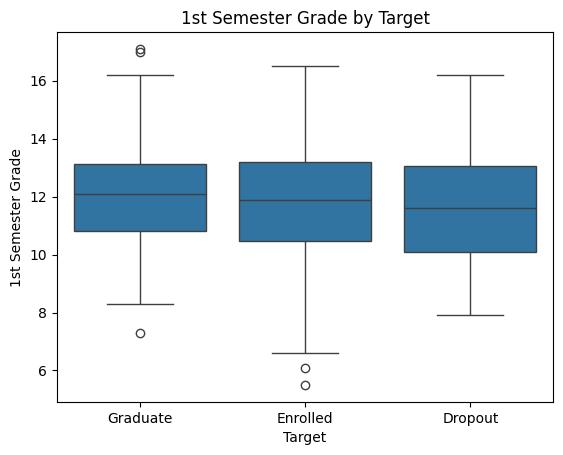

In [8]:
plt.figure()
sns.boxplot(
	x="Target",
	y="Curricular units 1st sem (grade)",
	data=df
)

plt.title("1st Semester Grade by Target")
plt.xlabel("Target")
plt.ylabel("1st Semester Grade")
plt.show()

In [9]:
phanBoDiem = df.groupby("Target")["Curricular units 1st sem (grade)"].agg(["mean", "median", "std"])
print(phanBoDiem)

print("""

Nhận xét:
- Nhóm Graduate có điểm trung bình cao nhất
- Nhóm Dropout có điểm trung vị thấp nhất
- Nhóm Enrolled có độ lệch chuẩn cao nhất (nhiều ngoại lệ nhất)
""")

               mean  median       std
Target                               
Dropout   11.718182    11.6  1.974641
Enrolled  11.830625    11.9  2.085017
Graduate  12.104365    12.1  1.772100


Nhận xét:
- Nhóm Graduate có điểm trung bình cao nhất
- Nhóm Dropout có điểm trung vị thấp nhất
- Nhóm Enrolled có độ lệch chuẩn cao nhất (nhiều ngoại lệ nhất)



# Bài 3 – Biểu đồ cột: Giới tính và kết quả
Yêu cầu:

Đếm số sinh viên theo Gender + Target.
Vẽ biểu đồ cột nhóm (grouped bar chart) để so sánh tỷ lệ Dropout / Enrolled / Graduate giữa Nam và Nữ.
Nhận xét: Ví dụ:  giới tính nào có tỷ lệ Dropout cao hơn?


In [10]:
countGenderTarget = df.groupby(["Gender", "Target"]).size().unstack()
print(countGenderTarget)

Target  Dropout  Enrolled  Graduate
Gender                             
Female       45        84       127
Male         43        76       125


In [11]:
pctCountGenderTarget = countGenderTarget.div(countGenderTarget.sum(axis=1), axis=0) * 100
print(pctCountGenderTarget)

Target    Dropout   Enrolled   Graduate
Gender                                 
Female  17.578125  32.812500  49.609375
Male    17.622951  31.147541  51.229508


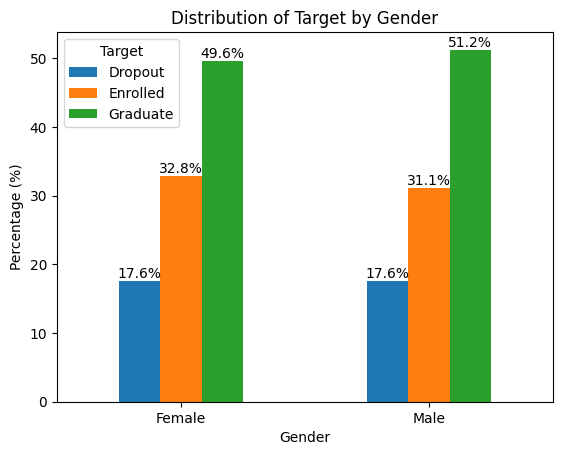

Nhận xét:
- Nam có tỉ lệ Graduate cao hơn
- Nữ có tỉ lệ Enrolled cao hơn
- Nam và nữ có tỉ lệ Dropout bằng nhau



In [12]:
ax = pctCountGenderTarget.plot(kind="bar")

plt.ylabel("Percentage (%)")
plt.title("Distribution of Target by Gender")
plt.xticks(rotation=0)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
		(p.get_x() + p.get_width() / 2, height),
		ha='center', va='bottom')

plt.legend(title="Target")
plt.show()

print("""Nhận xét:
- Nam có tỉ lệ Graduate cao hơn
- Nữ có tỉ lệ Enrolled cao hơn
- Nam và nữ có tỉ lệ Dropout bằng nhau
""")

# Bài 4 – So sánh ngành học
Yêu cầu:

Tính điểm trung bình đầu vào (Admission grade) và tỷ lệ Dropout theo từng Course.
Vẽ bar chart so sánh điểm đầu vào trung bình theo ngành.
Vẽ thêm biểu đồ thể hiện tỷ lệ Dropout (%).
Nhận xét: Ví dụ: ngành nào có tỷ lệ Dropout cao nhất? Ngành nào có điểm đầu vào cao nhưng vẫn Dropout nhiều?


In [13]:
meanAdmission = df.groupby("Course")["Admission grade"].mean()
print(meanAdmission)

Course
Computer Science    128.844304
Economics           132.434375
Engineering         130.300917
Management          130.052336
Psychology          132.666972
Name: Admission grade, dtype: float64


In [14]:
courseTarget = df.groupby(["Course", "Target"]).size().unstack()

dropoutRate = courseTarget.div(courseTarget.sum(axis=1), axis=0) * 100
dropoutRate = dropoutRate["Dropout"]

print(dropoutRate)

Course
Computer Science    22.784810
Economics           12.500000
Engineering         16.513761
Management          18.691589
Psychology          18.348624
Name: Dropout, dtype: float64


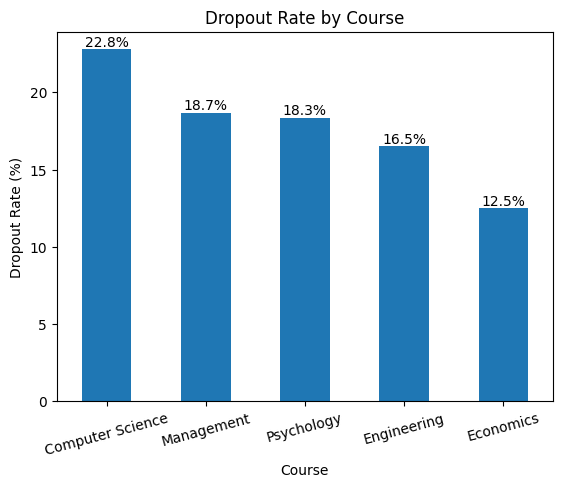

Nhận xét:
- Ngành Computer Science có tỉ lệ Dropout cao nhất
- Ngành Economics có tỉ lệ Dropout thấp nhất



In [15]:
dropout_sorted = dropoutRate.sort_values(ascending=False)

ax = dropout_sorted.plot(kind="bar")

plt.ylabel("Dropout Rate (%)")
plt.title("Dropout Rate by Course")
plt.xticks(rotation=15)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
		(p.get_x() + p.get_width()/2, height),
		ha='center', va='bottom')

plt.show()

print("""Nhận xét:
- Ngành Computer Science có tỉ lệ Dropout cao nhất
- Ngành Economics có tỉ lệ Dropout thấp nhất
""")